In [1]:
!pip install kaggle

In [2]:
from google.colab import files

# This opens a file picker — upload your kaggle.json file
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rishitachoudhury77","key":"22b8a05d534c86e079f36f61b2bcf446"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [4]:
!kaggle datasets download -d akshatagrawal9431/shipment-orders-dataset


Dataset URL: https://www.kaggle.com/datasets/akshatagrawal9431/shipment-orders-dataset
License(s): CC0-1.0
100% 197k/197k [00:00<00:00, 118MB/s]



In [5]:
!unzip shipment-orders-dataset.zip

Archive:  shipment-orders-dataset.zip
  inflating: orders_data.csv         


In [6]:
import pandas as pd

df = pd.read_csv('orders_data.csv')
df.head()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,01-03-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,15-08-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,10-01-2023,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,18-06-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,13-07-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [7]:
df.shape

(9994, 16)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order Id          9994 non-null   int64 
 1   Order Date        9994 non-null   object
 2   Ship Mode         9993 non-null   object
 3   Segment           9994 non-null   object
 4   Country           9994 non-null   object
 5   City              9994 non-null   object
 6   State             9994 non-null   object
 7   Postal Code       9994 non-null   int64 
 8   Region            9994 non-null   object
 9   Category          9994 non-null   object
 10  Sub Category      9994 non-null   object
 11  Product Id        9994 non-null   object
 12  cost price        9994 non-null   int64 
 13  List Price        9994 non-null   int64 
 14  Quantity          9994 non-null   int64 
 15  Discount Percent  9994 non-null   int64 
dtypes: int64(6), object(10)
memory usage: 1.2+ MB


In [9]:
df.isnull().sum()

,0
Order Id,0
Order Date,0
Ship Mode,1
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0


In [10]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'Not Available', 'unknown',
       'First Class', nan, 'Same Day'], dtype=object)

In [11]:
import numpy as np
df['Ship Mode'] = df['Ship Mode'].replace({'Not Available': np.nan, 'unknown': np.nan})
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', nan, 'First Class', 'Same Day'],
      dtype=object)

In [12]:
# find the mode
mode_ship = df['Ship Mode'].mode()[0]
print("Mode:", mode_ship)

# replace NaN with mode
df['Ship Mode'] = df['Ship Mode'].fillna(mode_ship)

# verify no nulls remain
print("Remaining nulls:", df['Ship Mode'].isna().sum())

Mode: Standard Class
Remaining nulls: 0


In [13]:
df.groupby('Category')['Sub Category'].count()

,Sub Category
Category,
Furniture,2121
Office Supplies,6026
Technology,1847


Total orders per category

* Furniture = 	2121
* Office Supplies= 	6026
* Technology=	1847

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')

# verify
df['Order Date'].dtype

#These date conversion is usefull for time-based analysis like monthly sales trends.

dtype('<M8[ns]')

In [15]:
df['Order Date'].sort_values(ascending=False)

,Order Date
2957,2023-12-31
7683,2023-12-31
5471,2023-12-31
8377,2023-12-31
910,2023-12-31
...,...
6195,2022-01-01
7971,2022-01-01
3790,2022-01-01
4278,2022-01-01


In [16]:
df.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent'],
      dtype='object')

In [17]:
(df[df['Category'] == 'Furniture']).shape
#We extracted out furniture rows
#then .shape-> just to calculate

(2121, 16)

In [18]:
#How much quanties of Office suplies sold?

total_quantity_office_suplies = (df[df['Category'] == 'Office Supplies']['Quantity']).sum()
print('total_quantity_office_suplies: ', total_quantity_office_suplies)

total_quantity_office_suplies:  22906


In [19]:
##How much quanties of category got sold?

total_quantity_categories = df.groupby('Category')['Quantity'].sum()
print('total_quantity_categories: ', total_quantity_categories)
#

total_quantity_categories:  Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64


In [20]:
#  calculate the **actual selling price** after discount
df['Selling Price'] = df['List Price'] * (1 - df['Discount Percent'] / 100)

# step 2 — average selling price per category
avg_price = df.groupby('Category')['Selling Price'].mean().reset_index()
#just renaming the selling price col for this output
avg_price.columns = ['Category', 'Avg Selling Price']

print(avg_price)

#This is the avg unit selling price after giving discount
#This is correct

          Category  Avg Selling Price
0        Furniture         337.265771
1  Office Supplies         115.108613
2       Technology         436.856253


In [21]:
df.groupby('Category')['List Price'].mean().round(2)

# This is the average selling price before discount(MRP)

,List Price
Category,
Furniture,349.55
Office Supplies,119.25
Technology,452.74


In [22]:
df.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'Selling Price'],
      dtype='object')

In [23]:
#Create neew col total sales -- selling price per quantity
df['Total Sales'] = df['Quantity'] * df['Selling Price']
df['Total Sales'] = df['Quantity'] * df['Selling Price']

# verify
df[['Quantity', 'Selling Price', 'Total Sales']].head()



,Quantity,Selling Price,Total Sales
0,2,254.8,509.6
1,3,708.1,2124.3
2,2,9.5,19.0
3,5,940.8,4704.0
4,2,19.0,38.0


In [24]:
df.groupby('Category')['Total Sales'].sum()

,Total Sales
Category,
Furniture,3720742.4
Office Supplies,3423675.1
Technology,3934910.7


In [25]:
# step 1 — calculate unit profit column
df['Unit Profit'] = df['Selling Price'] - df['cost price']

# step 2 — filter for Consumer segment and sum the profit
consumer_profit = df[df['Segment'] == 'Consumer']['Unit Profit'].sum()

print("Total Unit Profit for Consumer Segment:", consumer_profit)

Total Unit Profit for Consumer Segment: 101585.99999999999


In [26]:
# Extract data for the year 2023
data_2023 = df[df['Order Date'].dt.year == 2023]
print("Total orders in 2023:", len(data_2023))
data_2023.head()

Total orders in 2023: 4957


,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent,Selling Price,Total Sales,Unit Profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,254.8,509.6,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,708.1,2124.3,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,9.5,19.0,-0.5
8,9,2023-03-23,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,OFF-BI-10003910,20,20,3,2,19.6,58.8,-0.4
9,10,2023-05-16,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,OFF-AP-10002892,90,110,5,3,106.7,533.5,16.7


In [27]:
#Create a pivot table showing total quantity sold by state and category.
pivot_table = df.pivot_table(
    values='Quantity',
    index='State',
    columns='Category',
    aggfunc='sum',
    fill_value=0
)

pivot_table['Total'] = pivot_table.sum(axis=1)
pivot_table.loc['Grand Total'] = pivot_table.sum(axis=0)

pivot_table
#

Category,Furniture,Office Supplies,Technology,Total
State,,,,
Alabama,54,149,53,256
Arizona,188,501,173,862
Arkansas,43,135,62,240
California,1696,4566,1405,7667
Colorado,200,344,149,693
Connecticut,46,206,29,281
Delaware,64,244,59,367
District of Columbia,8,24,8,40
Florida,299,820,260,1379


/tmp/ipykernel_4172/3873831479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Total Sales', palette='Blues_d') # plot


Text(0, 0.5, 'Total Sales')

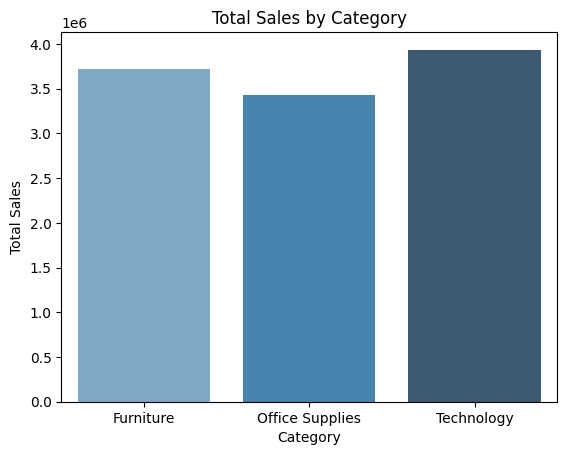

In [28]:
# Plot a bar chart of total sales by category.

import matplotlib.pyplot as plt
import seaborn as sns
category_sales = df.groupby('Category')['Total Sales'].sum().reset_index()   # prepare data
sns.barplot(data=category_sales, x='Category', y='Total Sales', palette='Blues_d') # plot
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')



In [29]:
# Correlation Analysis: Find the correlation between 'Quantity' and 'Unit_Profit'.

correlation = df['Quantity'].corr(df['Unit Profit'])
print("Correlation between Quantity and Unit Profit:", round(correlation, 4))

Correlation between Quantity and Unit Profit: 0.1628


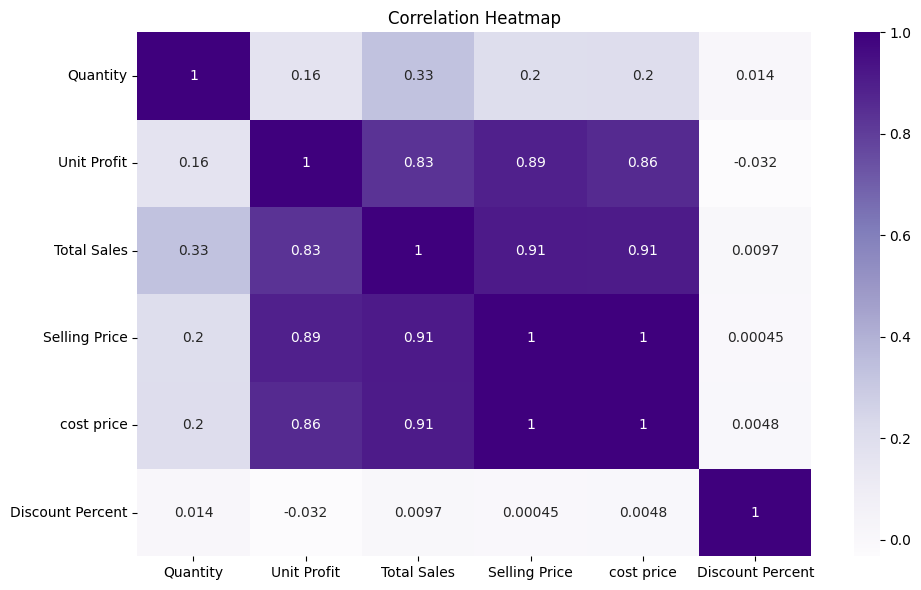

In [30]:
#correlation across all numerical columns using a heatmap:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[['Quantity', 'Unit Profit', 'Total Sales', 'Selling Price', 'cost price', 'Discount Percent']].corr(),
    annot=True,       # show numbers inside boxes
    cmap='Purples',  # red = positive, blue = negative
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [31]:
#18. Handling Duplicates: Identify and remove any duplicate records in the dataset.
#check how many duplicates exist
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


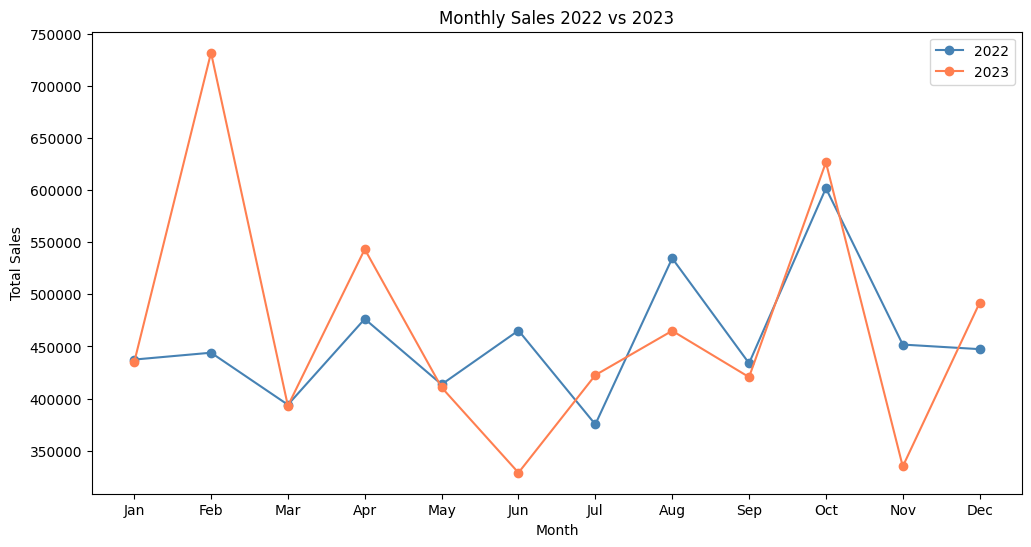

In [32]:
# 20. Time-Series Analysis: Plot a time-series graph of monthly sales.
df_2022 = df[df['Order Date'].dt.year == 2022]
df_2023 = df[df['Order Date'].dt.year == 2023]

monthly_2022 = df_2022.groupby(df_2022['Order Date'].dt.month)['Total Sales'].sum()
monthly_2023 = df_2023.groupby(df_2023['Order Date'].dt.month)['Total Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_2022.index, monthly_2022.values, marker='o', label='2022', color='steelblue')
plt.plot(monthly_2023.index, monthly_2023.values, marker='o', label='2023', color='coral')

plt.title('Monthly Sales 2022 vs 2023'), plt.xlabel('Month'), plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.show()

In [33]:
#What is the monthly growth rate in sales for furniture?

# step 1 — filter furniture and get monthly sales
furniture_monthly = df[df['Category'] == 'Furniture'].groupby(df['Order Date'].dt.to_period('M'))['Total Sales'].sum().reset_index()

# step 2 — calculate monthly growth rate
furniture_monthly['Growth Rate %'] = furniture_monthly['Total Sales'].pct_change() * 100

print(furniture_monthly)

   Order Date  Total Sales  Growth Rate %
0     2022-01     170244.5            NaN
1     2022-02     192062.9      12.815921
2     2022-03     150128.1     -21.833889
3     2022-04     162806.9       8.445321
4     2022-05     110578.8     -32.079783
5     2022-06     159075.8      43.857412
6     2022-07     137750.0     -13.406062
7     2022-08     162276.8      17.805299
8     2022-09     107151.9     -33.969674
9     2022-10     229024.8     113.738440
10    2022-11     203673.6     -11.069194
11    2022-12     137431.1     -32.523852
12    2023-01     126379.8      -8.041339
13    2023-02     217851.0      72.378022
14    2023-03     128026.4     -41.232127
15    2023-04     139036.1       8.599554
16    2023-05     144279.3       3.771107
17    2023-06      96551.5     -33.080144
18    2023-07     130781.9      35.452997
19    2023-08     230523.5      76.265599
20    2023-09     157022.7     -31.884298
21    2023-10     148430.2      -5.472139
22    2023-11     120961.5     -18

In [34]:
# outlier detection using IQR
Q1 = df.groupby('Category')['Selling Price'].transform('quantile', 0.25)
Q3 = df.groupby('Category')['Selling Price'].transform('quantile', 0.75)
IQR = Q3 - Q1

outliers = df[(df['Selling Price'] < (Q1 - 1.5 * IQR)) |
              (df['Selling Price'] > (Q3 + 1.5 * IQR))]

print("Total outliers found:", len(outliers))
outliers[['Category', 'Product Id', 'Selling Price']]

Total outliers found: 1136


,Category,Product Id,Selling Price
10,Furniture,FUR-TA-10001539,1658.7
13,Office Supplies,OFF-BI-10003656,401.8
16,Office Supplies,OFF-ST-10004186,649.9
24,Furniture,FUR-TA-10000577,988.0
27,Furniture,FUR-BO-10004834,2987.6
...,...,...,...
9948,Office Supplies,OFF-AP-10002945,2337.7
9957,Office Supplies,OFF-PA-10004039,211.2
9968,Office Supplies,OFF-BI-10004600,717.8
9979,Office Supplies,OFF-BI-10002026,426.8


/tmp/ipykernel_4172/2264877481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Selling Price', y='Category', palette='Set2', orient='h')


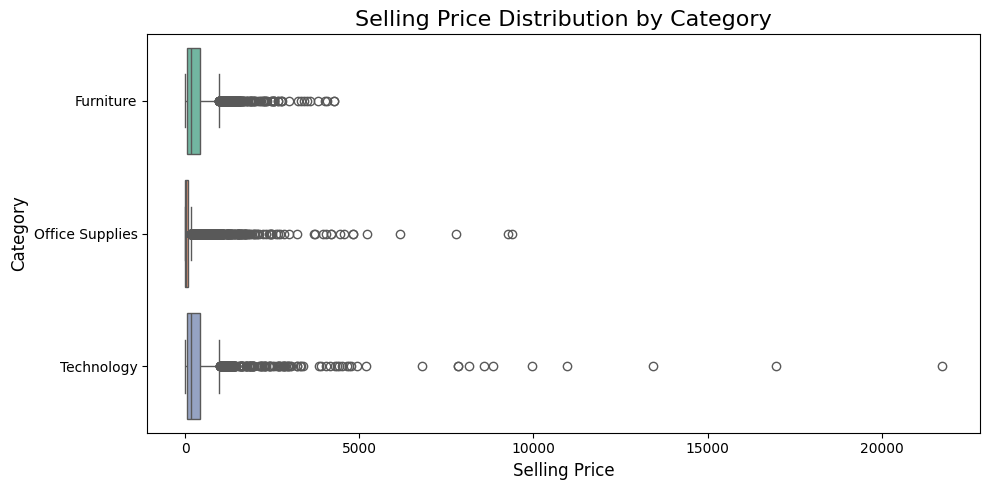

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Selling Price', y='Category', palette='Set2', orient='h')

plt.title('Selling Price Distribution by Category', fontsize=16)
plt.xlabel('Selling Price', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

In [36]:
# Build a simple linear regression model to predict 'Unit_Profit' based on 'Unit_Selling_Price' and 'Quantity'.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# step 1 — prepare data
X = df[['Selling Price', 'Quantity']]  # features
y = df['Unit Profit']                  # target

# step 2 — split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# step 3 — build and train model
model = LinearRegression()
model.fit(X_train, y_train)

# step 4 — predict
y_pred = model.predict(X_test)

# step 5 — evaluate
print("R² Score:  ", round(r2_score(y_test, y_pred), 4))
print("MSE:       ", round(mean_squared_error(y_test, y_pred), 4))
print("RMSE:      ", round(mean_squared_error(y_test, y_pred)**0.5, 4))
print("\nCoefficients:")
print(f"  Selling Price : {model.coef_[0]:.4f}")
print(f"  Quantity      : {model.coef_[1]:.4f}")
print(f"  Intercept     : {model.intercept_:.4f}")

R² Score:   0.8149
MSE:        1950.0702
RMSE:       44.1596

Coefficients:
  Selling Price : 0.0984
  Quantity      : -0.1110
  Intercept     : -1.0067


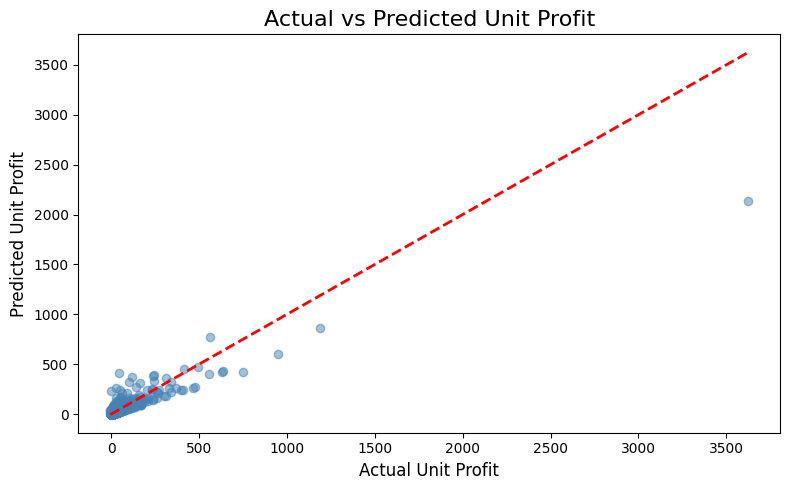

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--')  # perfect prediction line

plt.title('Actual vs Predicted Unit Profit', fontsize=16)
plt.xlabel('Actual Unit Profit', fontsize=12)
plt.ylabel('Predicted Unit Profit', fontsize=12)
plt.tight_layout()
plt.show()